In [11]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date, datetime, timedelta
from itertools import product
from RS.PreRun import PreRun, PostRun
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX


# path to data
read_path = "../../../data_ds_project/parquet_cleaned_energy/"
systems_cleaned = pd.read_csv("../../data/core/systems_cleaned.csv")
relevant_system_pairs = [(10, None), (50, None), (51, None)]

# results folder config
results_folder_str = './final_sarimax_errors/'
results_folder = Path(results_folder_str)
if not results_folder.is_dir():
    results_folder.mkdir()

### Helper function

In [6]:
def use_sarimax(df_train, df_ho, p=0, d=0, q=0, P=0, D=0, Q=0, s=0):

    #separate out the exogenous variables
    df_train = df_train.set_index('time')
    df_ho = df_ho.set_index('time')

    # Remove duplicate indices (keep first occurrence)
    df_train = df_train[~df_train.index.duplicated(keep='first')]
    df_ho = df_ho[~df_ho.index.duplicated(keep='first')]

    df_train = df_train.asfreq('h')
    df_ho = df_ho.asfreq('h')

    energy_train = df_train['energy']
    #energy_ho = df_ho['energy']

    exog_train = df_train.drop(columns=['energy'])
    exog_ho = df_ho.drop(columns=['energy'])

    #fit the model
    model_sarimax = SARIMAX(energy_train, exog=exog_train, order=(p,d,q), seasonal_order = (P,D,Q,s)).fit(maxiter=600, disp=False)
    #predict
    y_pred = model_sarimax.forecast(len(df_ho), exog=exog_ho) 

    #error = PostRun.custom_error(energy_ho, y_pred, 1,2)

    return y_pred#, error

### Training data

In [ ]:
p_choices = [2, 3]
#d_choices = [0, 1]
d_choices = [0]
q_choices = [0, 1]

for pair in relevant_system_pairs:
    system_id = pair[0]
    reader_type = pair[1]
    print(f'starting system {system_id}, {reader_type}')

    prerun = PreRun(system_id = system_id, meter_or_inverter = reader_type, path=read_path, systems_cleaned=systems_cleaned)
    prerun.load_data()
        
    prerun.fill_missing_hours()
    prerun.add_energy_features_only(include_last_year = True, remove_last_year_nans=True, highest_fourier_term_hour=2)
    #print(prerun.amended_data)

    prerun.add_weather_features_only()

    all_data=prerun.amended_data

    prerun.good_end_days_naive(10)
    prerun.tts_of_data_using_end_days(remove_first_year=False)

    system_recorded_max = prerun.data['energy'].max()

    #get all train/ho data sets ONCE so it's not redone for each (p,d,q)
    splits = []

    for pred_date in prerun.train_dates['date']:
        train_mask = (
            (all_data['time'] < pred_date - timedelta(days=1)) &
            (all_data['time'] >= pred_date - timedelta(days=10))
        )
        ho_mask = (
            (all_data['time'] >= pred_date - timedelta(days=1)) &
            (all_data['time'] < pred_date + timedelta(days=1))
        )

        train_data = all_data.loc[train_mask].reset_index(drop=True)
        ho_data = all_data.loc[ho_mask].reset_index(drop=True)

        splits.append((pred_date, train_data, ho_data))
    
    results_dict = {}
    # print(system_recorded_max)
    # print(ho_data)
    # print(ho_data.columns)

    for p,d,q in product(p_choices,d_choices,q_choices):
        print(f'     starting p={p}, d={d}, q={q}')
        errors=[]
        
        for pred_date, train_data, ho_data in splits:
            try: 
                y_pred = use_sarimax(train_data, ho_data, p=p, d=d, q=q)
                # print(f"original y_pred: {y_pred}")

                #make sure value between 0 and highest observed max
                y_pred = np.clip(y_pred, 0, system_recorded_max)
                #make sure that if it's not sunlight hours and irradiance = 0, then energy = 0
                darkness_mask = (~((ho_data['proportion_daytime']==0) & (ho_data['global_tilted_irradiance']==0))).astype(int) # = 0 when both sublight prop and irr are 0
                y_pred = y_pred*np.array(darkness_mask)
                # print(f"y_pred with insurance: {y_pred}")

                energy_ho = ho_data['energy']
                # print(f"energy_ho: {energy_ho}")
                # grab error data for *after* the skip-day.
                error = PostRun.custom_error(energy_ho.iloc[24:], y_pred.iloc[24:], 1,2)
                # print(f'error = {error}')
            except BaseException as e:
                print(f'FAILED: (p,d,q) = {p,d,q} --> {type(e).__name__}: {e}')
                error = -1
                

            errors.append(error)

        results_dict[f"{p},{d},{q}"] = errors
    all_errors_df = pd.DataFrame(results_dict)

    all_errors_df.to_csv(f'{results_folder_str}{system_id}_{reader_type}_sarimax_errors.csv', index = False)

starting system 10, None
     starting p=2, d=0, q=0


c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3

     starting p=2, d=0, q=1


c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary

     starting p=3, d=0, q=0


...

c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters

     starting p=3, d=0, q=0


c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3

     starting p=3, d=0, q=1


c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3

Print out errors

In [ ]:
for pair in relevant_system_pairs:
    system_id = pair[0]
    reader_type = pair[1]
    print(f'System {system_id}, {reader_type}, LinReg with streak = 1')
    final_error_dir_str = '../../data/modeling_final/'
    errors = pd.read_csv(f'{final_error_dir_str}/{system_id}_{reader_type}_linreg_errors.csv')
    hyperparams = errors.columns

    prerun = PreRun(system_id=system_id, meter_or_inverter=reader_type, path=read_path, systems_cleaned=systems_cleaned)
    prerun.load_data()
    system_recorded_max = prerun.data['energy'].max()
    print(f'recorded system max: {system_recorded_max}')
    for hp in hyperparams:
        err = errors[hp]
        print(f'  Hyperparameters: {hp}')
        print(f'     mean: {err.mean()}, median: {err.median()}, min: {err.min()}, max: {err.max()}, std: {err.std()}' )
        print('\n')

System 10, None, LinReg with streak = 1
recorded system max: 1.185825
  Hyperparameters: error
     mean: 0.006301510954218496, median: 0.0026304533544859498, min: 0.0, max: 0.1454695489572812, std: 0.010567874465099172


System 50, None, LinReg with streak = 1
recorded system max: 7.072975
  Hyperparameters: error
     mean: 0.12821317101060692, median: 0.0322100252946336, min: 0.0, max: 2.5331375139177883, std: 0.22244141320620422


System 51, None, LinReg with streak = 1
recorded system max: 7.2368749999999995
  Hyperparameters: error
     mean: 0.1611493405641434, median: 0.049502957886832843, min: 0.0, max: 4.187207336735569, std: 0.2961294710602631




### Now compute on test set

In [ ]:
all_errors = []
for pair in relevant_system_pairs:
    system_id = pair[0]
    reader_type = pair[1]
    print(f'starting system {system_id}, {reader_type}')

    prerun = PreRun(system_id = system_id, meter_or_inverter = reader_type, path=read_path, systems_cleaned=systems_cleaned)
    prerun.load_data()
        
    prerun.fill_missing_hours()
    prerun.add_energy_features_only(include_last_year = True, remove_last_year_nans=True, highest_fourier_term_hour=2)
    #print(prerun.amended_data)

    prerun.add_weather_features_only()

    all_data=prerun.amended_data

    prerun.good_end_days_naive(10)
    prerun.tts_of_data_using_end_days(remove_first_year=False)

    system_recorded_max = prerun.data['energy'].max()

    splits = []

    for pred_date in prerun.test_dates['date']:
        train_mask = (
            (all_data['time'] < pred_date - timedelta(days=1)) &
            (all_data['time'] >= pred_date - timedelta(days=10))
        )
        ho_mask = (
            (all_data['time'] >= pred_date - timedelta(days=1)) &
            (all_data['time'] < pred_date + timedelta(days=1))
        )

        train_data = all_data.loc[train_mask].reset_index(drop=True)
        ho_data = all_data.loc[ho_mask].reset_index(drop=True)

        splits.append((pred_date, train_data, ho_data))
    
    # print(system_recorded_max)
    # print(ho_data)
    # print(ho_data.columns)

    #choose p,d,q
    d=0
    q=0
    if system_id == 10:
        p=2
    elif (system_id == 50) | (system_id == 51):
        p=3

    
    system_errors=[]  
    for pred_date, train_data, ho_data in splits:
        try: 
            y_pred = use_sarimax(train_data, ho_data, p=p, d=d, q=q)
            # print(f"original y_pred: {y_pred}")

            #make sure value between 0 and highest observed max
            y_pred = np.clip(y_pred, 0, system_recorded_max)
            #make sure that if it's not sunlight hours and irradiance = 0, then energy = 0
            darkness_mask = (~((ho_data['proportion_daytime']==0) & (ho_data['global_tilted_irradiance']==0))).astype(int) # = 0 when both sublight prop and irr are 0
            y_pred = y_pred*np.array(darkness_mask)
            # print(f"y_pred with insurance: {y_pred}")

            energy_ho = ho_data['energy']
            # print(f"energy_ho: {energy_ho}")
            
            error = PostRun.custom_error(energy_ho.iloc[24:], y_pred.iloc[24:], 1,2)
            # print(f'error = {error}')
        except Exception as e:
            print(f'FAILED: (p,d,q) = {p,d,q} --> {type(e).__name__}: {e}')
            error = -1
        system_errors.append(error)
    system_errors_df = pd.DataFrame({'error':system_errors})
    system_errors_df.to_csv(f'{results_folder_str}{system_id}_test_set_sarimax_errors.csv', index = False)

starting system 10, None


c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


starting system 50, None


c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3

starting system 51, None


c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3

## Test errors histograms

System 10


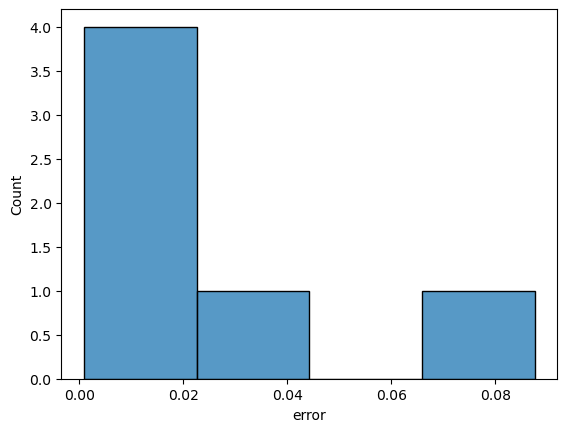

mean = 0.02327, median = 0.00619, min = 0.00091, max = 0.08763, std = 0.03446



System 50


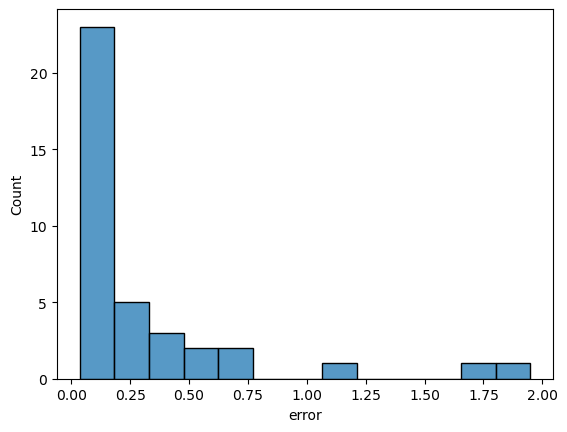

mean = 0.31254, median = 0.15889, min = 0.03510, max = 1.94948, std = 0.42883



System 51


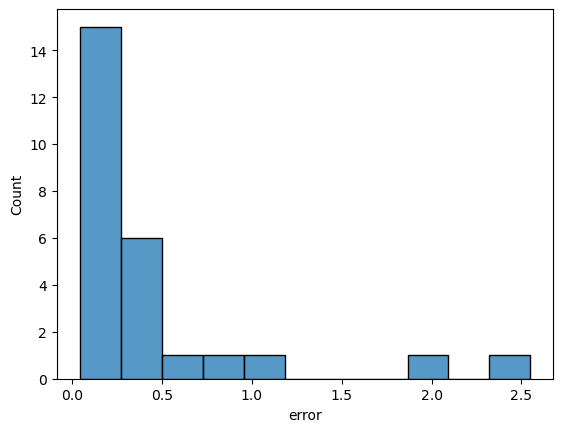

mean = 0.41352, median = 0.16540, min = 0.04007, max = 2.55066, std = 0.59126





In [18]:
systems = [10,50,51]
for system in systems:
    print('System',system)
    df = pd.read_csv(f'{results_folder_str}{system}_test_set_sarimax_errors.csv')
    sns.histplot(
        x = df['error'],

    )
    plt.show()
    print(f'mean = {df['error'].mean():.5f}, median = {df['error'].median():.5f}, '
           + f'min = {df['error'].min():.5f}, max = {df['error'].max():.5f}, std = {df['error'].std():.5f}')
    print('\n\n')

### Let's try graphing the actual performance on the last test-day.

In [31]:
def last_test_date_data(system_id: int, met_or_inv: str|None):
    prerun = PreRun(system_id = system_id, meter_or_inverter = met_or_inv, path=read_path, systems_cleaned=systems_cleaned)
    prerun.load_data()
        
    prerun.fill_missing_hours()
    prerun.add_energy_features_only(include_last_year = True, remove_last_year_nans=True, highest_fourier_term_hour=2)
    #print(prerun.amended_data)

    prerun.add_weather_features_only()

    all_data=prerun.amended_data

    prerun.good_end_days_naive(10)
    prerun.tts_of_data_using_end_days(remove_first_year=False)

    system_recorded_max = prerun.data['energy'].max()

    splits = []
    data_to_return = []
    
    last_pred_date = prerun.test_dates['date'].max()
    train_mask = (
        (all_data['time'] < last_pred_date - timedelta(days=1)) &
        (all_data['time'] >= last_pred_date - timedelta(days=10))
    )
    ho_mask = (
        (all_data['time'] >= last_pred_date - timedelta(days=1)) &
        (all_data['time'] < last_pred_date + timedelta(days=1))
    )

    train_data = all_data.loc[train_mask].reset_index(drop=True)
    ho_data = all_data.loc[ho_mask].reset_index(drop=True)

    splits.append((last_pred_date, train_data, ho_data))
    data_to_return.append(last_pred_date)
    data_to_return.append(ho_data)
    
    # print(system_recorded_max)
    # print(ho_data)
    # print(ho_data.columns)

    #choose p,d,q
    d=0
    q=0
    if system_id == 10:
        p=2
    elif (system_id == 50) | (system_id == 51):
        p=3
    
    for last_pred_date, train_data, ho_data in splits:
        try: 
            y_pred = use_sarimax(train_data, ho_data, p=p, d=d, q=q)
            # print(f"original y_pred: {y_pred}")

            #make sure value between 0 and highest observed max
            y_pred = np.clip(y_pred, 0, system_recorded_max)
            #make sure that if it's not sunlight hours and irradiance = 0, then energy = 0
            darkness_mask = (~((ho_data['proportion_daytime']==0) & (ho_data['global_tilted_irradiance']==0))).astype(int) # = 0 when both sublight prop and irr are 0
            y_pred = y_pred*np.array(darkness_mask)
            data_to_return.append(y_pred)
        except Exception as e:
            print(f'FAILED: (p,d,q) = {p,d,q} --> {type(e).__name__}: {e}')
            error = -1

    return data_to_return

In [32]:
last_date_10, last_data_10, last_preds_10 = last_test_date_data(10, None)
last_date_50, last_data_50, last_preds_50 = last_test_date_data(50, None)
last_date_51, last_data_51, last_preds_51 = last_test_date_data(51, None)

c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [30]:
assert(last_preds_10.shape == (48, ))

In [36]:
last_data_10.loc[7:14, ['time', 'energy']]

,time,energy
7,2022-09-08 07:00:00,0.218870
8,2022-09-08 08:00:00,0.419978
9,2022-09-08 09:00:00,0.573855
10,2022-09-08 10:00:00,0.492381
11,2022-09-08 11:00:00,0.391028
12,2022-09-08 12:00:00,0.253825
13,2022-09-08 13:00:00,0.448139
14,2022-09-08 14:00:00,0.150549


In [ ]:
last_data_10['time_of_day'] = last_data_10['time'].dt.time

In [ ]:
last_data_10[['time', 'time_of_day', 'energy']].head()

,time,time_of_day,energy
0,2022-09-08 00:00:00,00:00:00,0.0
1,2022-09-08 01:00:00,01:00:00,0.0
2,2022-09-08 02:00:00,02:00:00,0.0
3,2022-09-08 03:00:00,03:00:00,0.0
4,2022-09-08 04:00:00,04:00:00,0.0


In [39]:
last_preds_10[24+7:24+14]

2022-09-09 07:00:00    0.069251
2022-09-09 08:00:00    0.138820
2022-09-09 09:00:00    0.278537
2022-09-09 10:00:00    0.429315
2022-09-09 11:00:00    0.558005
2022-09-09 12:00:00    0.640481
2022-09-09 13:00:00    0.607418
Freq: h, Name: predicted_mean, dtype: float64

In [56]:
def graph_last_test_date_data(system_id: int, met_or_inv: str|None):
    test_date, test_data, y_pred = last_test_date_data(system_id, met_or_inv)
    # show that we have 2 days of data, for Sarimax continuity reasons
    assert (test_data.shape == (48, 10))
    assert (y_pred.shape == (48,))
    # trim to the test date
    x_true = test_data.loc[24:, 'time'].values
    y_true = test_data.loc[24:, 'energy'].values
    y_pred = y_pred[24:].values
    # graph prediction
    fig, ax = plt.subplots()
    sns.lineplot(x = x_true, y = y_pred, label = 'Predicted hourly energy')
    sns.lineplot(x = x_true, y = y_true, label = 'True energy')
    plt.xlabel('Time')
    ax.tick_params(axis='x', labelrotation=30)
    plt.ylabel('Energy (kWh)')
    plt.show()

c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


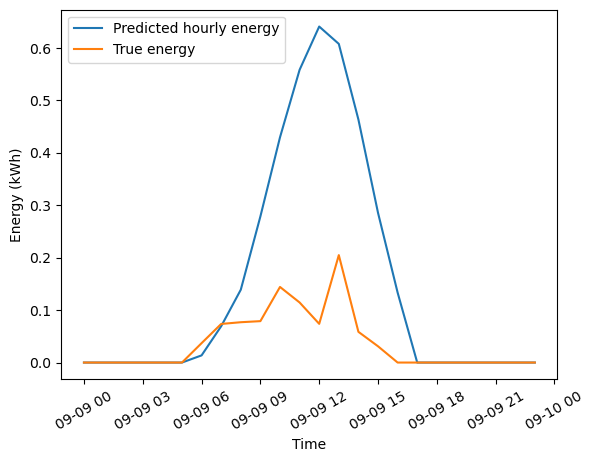

In [57]:
graph_last_test_date_data(10, None)

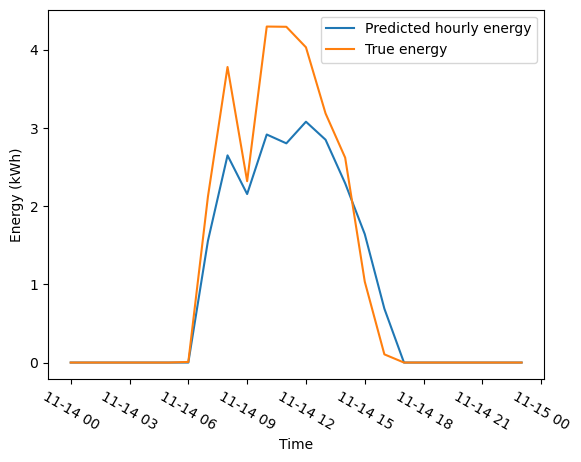

In [55]:
graph_last_test_date_data(50, None)

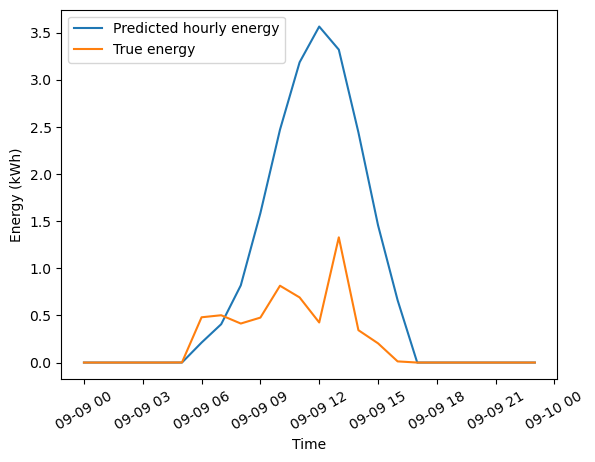

In [85]:
graph_last_test_date_data(51, None)

OK, so performance on any particular test-day is a tossup, since the model wants to predict a 'typical' day.  Averaged test results?

In [102]:
def averaged_test_performance_for_graphing(system_id: int, met_or_inv: str|None):
    prerun = PreRun(system_id = system_id, meter_or_inverter = met_or_inv, path=read_path, systems_cleaned=systems_cleaned)
    prerun.load_data()
        
    prerun.fill_missing_hours()
    prerun.add_energy_features_only(include_last_year = True, remove_last_year_nans=True, highest_fourier_term_hour=2)
    #print(prerun.amended_data)

    prerun.add_weather_features_only()

    all_data=prerun.amended_data

    prerun.good_end_days_naive(10)
    prerun.tts_of_data_using_end_days(remove_first_year=False)

    system_recorded_max = prerun.data['energy'].max()
    
    my_test_dates = prerun.test_dates['date']
    my_test_dates_short = prerun.test_dates['date'].dt.date
    num_dates = len(my_test_dates)
    splits = []

    for j in range(num_dates):
        pred_date = my_test_dates.iloc[j]
        pred_date_short = my_test_dates_short.iloc[j]
        train_mask = (
            (all_data['time'] < pred_date - timedelta(days=1)) &
            (all_data['time'] >= pred_date - timedelta(days=10))
        )
        ho_mask = (
            (all_data['time'] >= pred_date - timedelta(days=1)) &
            (all_data['time'] < pred_date + timedelta(days=1))
        )

        train_data = all_data.loc[train_mask].reset_index(drop=True)
        ho_data = all_data.loc[ho_mask].reset_index(drop=True)

        splits.append((pred_date_short, train_data, ho_data))
    
    # print(system_recorded_max)
    # print(ho_data)
    # print(ho_data.columns)

    #choose p,d,q
    d=0
    q=0
    if system_id == 10:
        p=2
    elif (system_id == 50) | (system_id == 51):
        p=3

    num_dates = len(my_test_dates)
    true_data = pd.DataFrame(
        data = np.zeros(shape=(24, num_dates)),
        columns = [*[f'{pred_date}_energy' for pred_date in my_test_dates_short]]
    )
    pred_data = pd.DataFrame(
        data = np.zeros(shape=(24, num_dates)),
        columns = [*[f'{pred_date}_pred' for pred_date in my_test_dates_short]]
    )
    time_set = False
    for pred_date, train_data, ho_data in splits:
        try: 
            y_pred = use_sarimax(train_data, ho_data, p=p, d=d, q=q)
            # print(f"original y_pred: {y_pred}")

            #make sure value between 0 and highest observed max
            y_pred = np.clip(y_pred, 0, system_recorded_max)
            #make sure that if it's not sunlight hours and irradiance = 0, then energy = 0
            darkness_mask = (~((ho_data['proportion_daytime']==0) & (ho_data['global_tilted_irradiance']==0))).astype(int) # = 0 when both sublight prop and irr are 0
            y_pred = y_pred*np.array(darkness_mask)
        except Exception as e:
            print(f'FAILED: (p,d,q) = {p,d,q} --> {type(e).__name__}: {e}')
            error = -1
        assert(ho_data.shape == (48, 10))
        assert(y_pred.shape == (48, ))
        # get data for dates
        ho_data = ho_data.loc[24:]
        ho_data = ho_data[['time', 'energy']]
        ho_data['time_of_day'] = ho_data['time'].dt.time
        y_pred = y_pred[24:]
        if not time_set:
            true_data.loc[:, 'time_of_day'] = ho_data.loc[:, 'time_of_day']
            pred_data.loc[:, 'time_of_day'] = ho_data.loc[:, 'time_of_day']
            time_set = True
        true_data.loc[:, f'{pred_date}_energy'] = ho_data['energy']
        pred_data.loc[:, f'{pred_date}_pred'] = y_pred
    print(true_data.iloc[10:14, 0])
    true_nontime_cols = [col_name for col_name in true_data.columns if 'time' not in col_name]
    pred_nontime_cols = [col_name for col_name in pred_data.columns if 'time' not in col_name]
    true_data.loc[:, 'mean_energy'] = true_data[true_nontime_cols].mean(axis=1)
    pred_data.loc[:, 'mean_pred'] = pred_data[pred_nontime_cols].mean(axis=1)
    total_average = pd.merge(
        left=true_data[['time_of_day', 'mean_energy']],
        right=pred_data[['time_of_day', 'mean_pred']],
        how='inner',
        left_on='time_of_day',
        right_on='time_of_day'
    )
    return total_average

In [103]:
avg_10 = averaged_test_performance_for_graphing(10, None)
avg_50 = averaged_test_performance_for_graphing(50, None)
avg_51 = averaged_test_performance_for_graphing(51, None)

c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


10   NaN
11   NaN
12   NaN
13   NaN
Name: 2021-09-19_energy, dtype: float64


c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3

10   NaN
11   NaN
12   NaN
13   NaN
Name: 2021-11-23_energy, dtype: float64


c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3\envs\requests_pack\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ch83b\anaconda3

10   NaN
11   NaN
12   NaN
13   NaN
Name: 2021-06-17_energy, dtype: float64


In [76]:
avg_10.head()

,time_of_day,mean_energy,mean_pred
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN


In [ ]:
def graph_avg_test_data(system_id: int, met_or_inv: str|None, avg_df: pd.DataFrame):
    # graph prediction
    fig, ax = plt.subplots()
    sns.lineplot(data = avg_df, x = 'time_of_day',
                 y='mean_pred', label = 'Predicted hourly energy (avg. of test_days)')
    sns.lineplot(data = avg_df, x = 'time_of_day',
                 y='mean_energy', label = 'Actual hourly energy (avg. of test_days)')
    plt.xlabel('Time')
    ax.tick_params(axis='x', labelrotation=30)
    plt.ylabel('Energy (kWh)')
    plt.Title(f'Averaged Test performance for SARIMAX model, System {system_id}')
    plt.show()

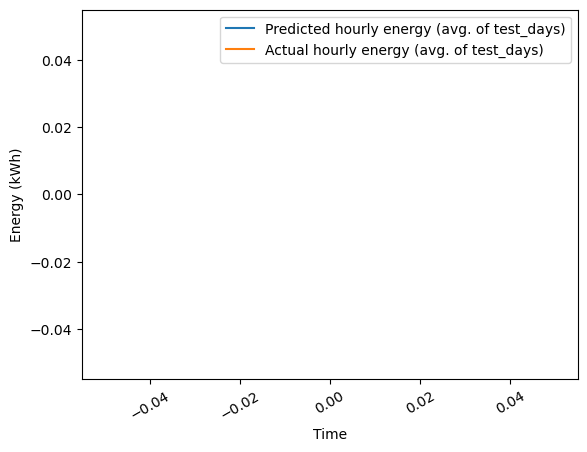

In [73]:
graph_avg_test_data(10, None, avg_10)